In [37]:
%pip install perceval-quandela
%pip install torch
%pip install merlinquantum

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import itertools

from math import comb

import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import perceval as pcvl
from perceval.components import BS, PS, Circuit
from perceval.backends import BackendFactory
from itertools import permutations

from itertools import combinations_with_replacement
import re

In [ ]:



# reload dataframe if needed
ds = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train",
)

df = pd.DataFrame(ds)

# remove date column
surface_cols = [col for col in df.columns if col != "Date"]

tenors = []
maturities = []

for col in surface_cols:
    t = float(re.search(r"Tenor : (.*?);", col).group(1))
    m = float(re.search(r"Maturity : (.*)", col).group(1))
    tenors.append(t)
    maturities.append(m)

tenors = np.array(tenors)
maturities = np.array(maturities)

print("Surface points:", len(surface_cols))
print("Tenor sample:", tenors[:5])
print("Maturity sample:", maturities[:5])

Surface points: 224
Tenor sample: [1. 2. 3. 4. 5.]
Maturity sample: [0.08333333 0.08333333 0.08333333 0.08333333 0.08333333]


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [14]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

r = 5
pca = PCA(n_components=r)
factors = pca.fit_transform(data_scaled)

print("Factor shape:", factors.shape)
print("Explained variance:", np.sum(pca.explained_variance_ratio_))

Factor shape: (494, 5)
Explained variance: 0.9997859107422641


In [15]:
X = factors[:-1]
Y = factors[1:]

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# Torch versions (for readout training)
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
Y_test_t  = torch.tensor(Y_test,  dtype=torch.float32).to(device)

# Numpy versions (for quantum reservoir)
X_train_np = X_train
X_test_np  = X_test


In [24]:
def permanent(matrix):
    n = matrix.shape[0]
    perm_sum = 0
    for p in permutations(range(n)):
        prod = 1
        for i in range(n):
            prod *= matrix[i, p[i]]
        perm_sum += prod
    return perm_sum

In [61]:
m = 10      # modes
n = 5      # photons

circuit = Circuit(m)

# Random interferometer
for i in range(m - 1):
    circuit.add(i, BS())
    circuit.add(i, PS(np.random.uniform(0, 2*np.pi)))

for i in reversed(range(m - 1)):
    circuit.add(i, BS())

U_mode = circuit.compute_unitary()

In [62]:
def generate_fock_basis(m, n):
    basis = []
    for combi in combinations_with_replacement(range(m), n):
        state = [0] * m
        for idx in combi:
            state[idx] += 1
        basis.append(tuple(state))
    return basis

basis = generate_fock_basis(m, n)
dim = len(basis)

basis_index = {state: i for i, state in enumerate(basis)}

print("Hilbert dimension:", dim)

Hilbert dimension: 2002


In [30]:
import math

In [63]:
def build_fock_unitary(U_mode, basis):

    dim = len(basis)
    U_fock = np.zeros((dim, dim), dtype=complex)

    for i, out_state in enumerate(basis):
        for j, in_state in enumerate(basis):

            rows = []
            for mode, count in enumerate(out_state):
                rows += [mode] * count

            cols = []
            for mode, count in enumerate(in_state):
                cols += [mode] * count

            submatrix = U_mode[np.ix_(rows, cols)]

            perm = permanent(submatrix)

            norm = np.sqrt(
                np.prod([math.factorial(x) for x in out_state]) *
                np.prod([math.factorial(x) for x in in_state])
            )

            U_fock[i, j] = perm / norm

    return U_fock

U_fock = build_fock_unitary(U_mode, basis)
print("Fock unitary built.")

Fock unitary built.


In [65]:
init_state = (1,1,1,1,1,0,0,0,0,0)

psi0 = np.zeros(dim, dtype=complex)
psi0[basis_index[init_state]] = 1.0

In [ ]:
# m = 5  # number of modes

# photons = 2

# circuit = Circuit(m)

# # Random beamsplitter network
# for i in range(m - 1):
#     circuit.add(i, BS())
#     circuit.add(i, PS(np.random.uniform(0, 2*np.pi)))

In [69]:
def input_fock_unitary(alpha, scale=0.2):

    U_in = np.eye(dim, dtype=complex)

    # pad alpha if needed
    if len(alpha) < m:
        alpha_extended = np.zeros(m)
        alpha_extended[:len(alpha)] = alpha
    else:
        alpha_extended = alpha[:m]

    for i, state in enumerate(basis):
        phase = 1.0
        for mode in range(m):
            phase *= np.exp(1j * scale * alpha_extended[mode]) ** state[mode]
        U_in[i, i] = phase

    return U_in

In [ ]:
# def build_input_circuit(alpha, input_scale=0.2):
#     circ = Circuit(m)
#     for mode in range(m):
#         theta = input_scale * alpha[mode]
#         circ.add(mode, PS(theta))
#     return circ

In [ ]:
# backend = BackendFactory.get_backend("SLOS")  # Fock simulator
# backend.set_circuit(circuit)

In [ ]:
# def input_unitary(alpha):
#     # build phase shift matrix on modes
#     phase_shifts = np.exp(1j * alpha)

#     # build diagonal matrix in Fock space
#     U_input = np.eye(dim, dtype=complex)

#     for i, state in enumerate(basis):
#         phase = 1
#         for mode in range(m):
#             phase *= phase_shifts[mode] ** state[mode]
#         U_input[i, i] = phase

#     return U_input

recurrent evolution - memory lives in psi

In [89]:
def run_quantum_reservoir(X, return_last_state=False):

    psi = psi0.copy()
    Z = []

    for alpha in X:

        U_in = input_fock_unitary(alpha)
        psi = U_fock @ (U_in @ psi)

        probs = np.abs(psi)**2
        z = np.zeros(m)

        for i, state in enumerate(basis):
            for mode in range(m):
                z[mode] += probs[i] * state[mode]

        Z.append(z)

    if return_last_state:
        return np.array(Z), psi
    else:
        return np.array(Z)

In [ ]:
# class RecurrentQuantumReservoir(nn.Module):
#     def __init__(self, input_dim=5, modes=5):
#         super().__init__()
#         self.modes = modes
#         self.readout = nn.Linear(modes, input_dim)

#     def forward(self, X):

#         outputs = []
#         z_prev = np.zeros(self.modes)

#         # Ensure tensor
#         if isinstance(X, np.ndarray):
#             X = torch.tensor(X, dtype=torch.float32)

#         for t in range(X.shape[0]):
#             alpha = X[t].detach().cpu().numpy()

#             z = quantum_step(alpha, z_prev)
#             z_prev = z.copy()

#             z_tensor = torch.tensor(z, dtype=torch.float32).to(X.device)

#             y = self.readout(z_tensor)
#             outputs.append(y)

#         return torch.stack(outputs)

In [102]:
print("Generating quantum features...")

Z_full, psi_last = run_quantum_reservoir(X, return_last_state=True)
Z_train = run_quantum_reservoir(X_train)



Generating quantum features...


ridge regression

In [ ]:
# lambda_reg = 1e-4
# I = np.eye(Z_train.shape[1])

# W_out = np.linalg.inv(Z_train.T @ Z_train + lambda_reg * I) @ Z_train.T @ Y_train

In [92]:
class Readout(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

model = Readout(m, r).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

In [93]:
epochs = 30000

for epoch in range(epochs):

    model.train()
    optimizer.zero_grad()

    Y_pred = model(Z_train_t)
    loss = criterion(Y_pred, Y_train_t)

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 48.239883
Epoch 50, Loss: 47.853245
Epoch 100, Loss: 47.590553
Epoch 150, Loss: 47.401295
Epoch 200, Loss: 47.252380
Epoch 250, Loss: 47.127522
Epoch 300, Loss: 47.017464
Epoch 350, Loss: 46.916031
Epoch 400, Loss: 46.819340
Epoch 450, Loss: 46.725380
Epoch 500, Loss: 46.633205
Epoch 550, Loss: 46.542431
Epoch 600, Loss: 46.452919
Epoch 650, Loss: 46.364605
Epoch 700, Loss: 46.277473
Epoch 750, Loss: 46.191498
Epoch 800, Loss: 46.106663
Epoch 850, Loss: 46.022938
Epoch 900, Loss: 45.940281
Epoch 950, Loss: 45.858658
Epoch 1000, Loss: 45.778046
Epoch 1050, Loss: 45.698395
Epoch 1100, Loss: 45.619671
Epoch 1150, Loss: 45.541847
Epoch 1200, Loss: 45.464867
Epoch 1250, Loss: 45.388721
Epoch 1300, Loss: 45.313366
Epoch 1350, Loss: 45.238766
Epoch 1400, Loss: 45.164902
Epoch 1450, Loss: 45.091751
Epoch 1500, Loss: 45.019283
Epoch 1550, Loss: 44.947464
Epoch 1600, Loss: 44.876297
Epoch 1650, Loss: 44.805744
Epoch 1700, Loss: 44.735779
Epoch 1750, Loss: 44.666409
Epoch 1800, Los

In [94]:
model.eval()

with torch.no_grad():
    Y_pred_test = model(Z_test_t)
    test_loss = criterion(Y_pred_test, Y_test_t)

print("Test MSE (PCA space):", test_loss.item())

Test MSE (PCA space): 29.95474624633789


In [95]:
Y_pred_np = Y_pred_test.cpu().numpy()
Y_test_np = Y_test

Y_pred_surface_scaled = pca.inverse_transform(Y_pred_np)
Y_test_surface_scaled = pca.inverse_transform(Y_test_np)

Y_pred_surface = scaler.inverse_transform(Y_pred_surface_scaled)
Y_test_surface = scaler.inverse_transform(Y_test_surface_scaled)

surface_mse = np.mean((Y_pred_surface - Y_test_surface)**2)

print("Surface MSE:", surface_mse)

Surface MSE: 0.0002637762556444434


In [96]:
print(np.mean(np.abs(Y_test_surface)))

0.2120852277537596


In [77]:
import seaborn as sns
import matplotlib.pyplot as plt


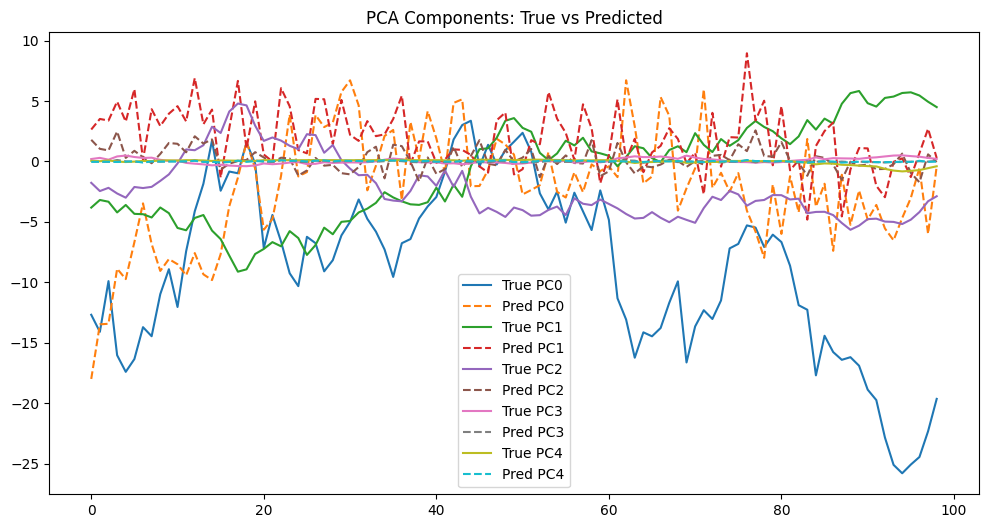

In [97]:
plt.figure(figsize=(12,6))

for i in range(r):
    plt.plot(Y_test[:, i], label=f"True PC{i}")
    plt.plot(Y_pred_test[:, i], '--', label=f"Pred PC{i}")

plt.title("PCA Components: True vs Predicted")
plt.legend()
plt.show()

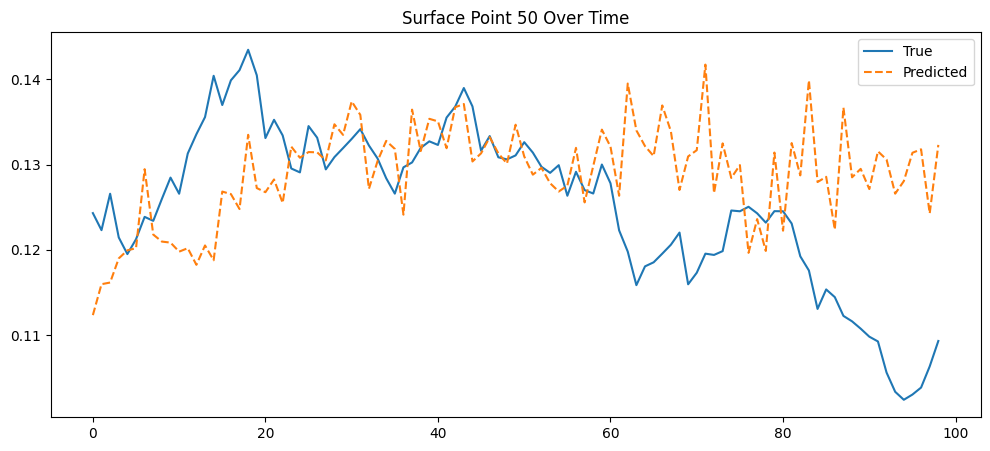

In [98]:
point_idx = 50  # choose surface column

plt.figure(figsize=(12,5))
plt.plot(Y_test_surface[:, point_idx], label="True")
plt.plot(Y_pred_surface[:, point_idx], '--', label="Predicted")
plt.title(f"Surface Point {point_idx} Over Time")
plt.legend()
plt.show()

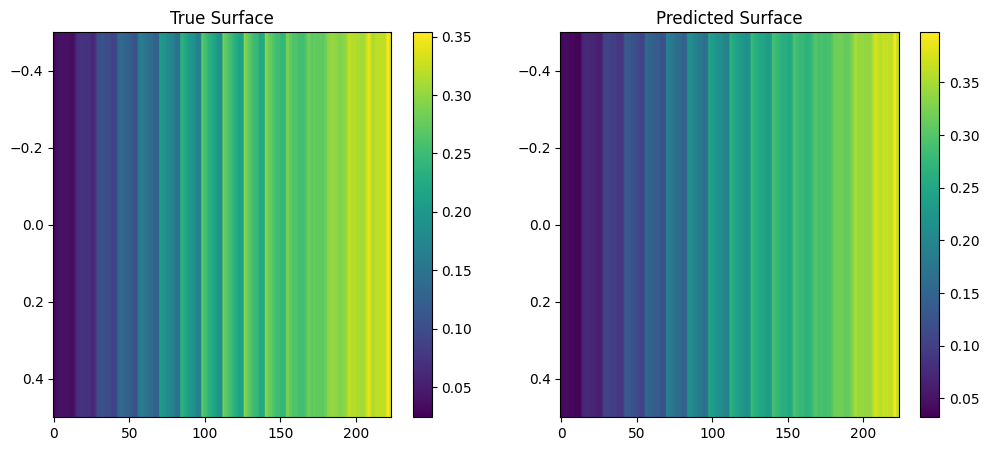

In [81]:
sample_idx = 10  # pick a test sample

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(Y_test_surface[sample_idx].reshape(1,-1), aspect="auto")
plt.title("True Surface")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(Y_pred_surface[sample_idx].reshape(1,-1), aspect="auto")
plt.title("Predicted Surface")
plt.colorbar()

plt.show()

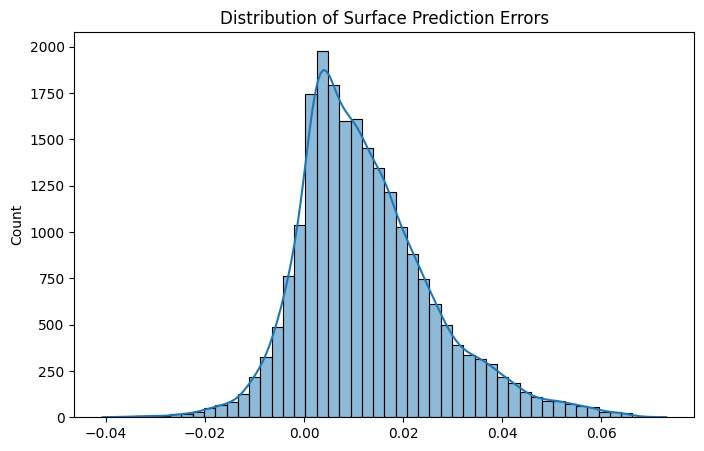

In [83]:
plt.figure(figsize=(8,5))
sns.histplot(error_surface.flatten(), bins=50, kde=True)
plt.title("Distribution of Surface Prediction Errors")
plt.show()

In [84]:
relative_error = np.abs(error_surface) / (np.abs(Y_test_surface) + 1e-8)
print("Mean Relative Error (%):", np.mean(relative_error)*100)

Mean Relative Error (%): 8.039948630447903


In [85]:
# Persistence model
Y_naive = Y_test_surface[:-1]
Y_true  = Y_test_surface[1:]

naive_mse = np.mean((Y_naive - Y_true)**2)

print("Naive Persistence Surface MSE:", naive_mse)

Naive Persistence Surface MSE: 1.3027917209306169e-05


In [99]:
psi_future = psi_last.copy()
x_current = X[-1]

In [104]:
W = model.linear.weight.detach().cpu().numpy()   # shape (r, m)
b = model.linear.bias.detach().cpu().numpy()     # shape (r,)

In [105]:
print("z shape:", z.shape)
print("W_out shape:", W_out.shape)

z shape: (10,)
W_out shape: (10, 5)


In [107]:
H = 50
future_predictions = []

for h in range(H):

    # 1. Quantum encoding
    U_in = input_fock_unitary(x_current)

    # 2. Evolve quantum state
    psi_future = U_fock @ (U_in @ psi_future)

    # 3. Extract features
    probs = np.abs(psi_future)**2
    z = np.zeros(m)
    for i, state in enumerate(basis):
        for mode in range(m):
            z[mode] += probs[i] * state[mode]

    # 4. Predict next PCA vector
    y_next = W @ z + b

    future_predictions.append(y_next)

    # 5. Feed prediction back as input
    x_current = y_next

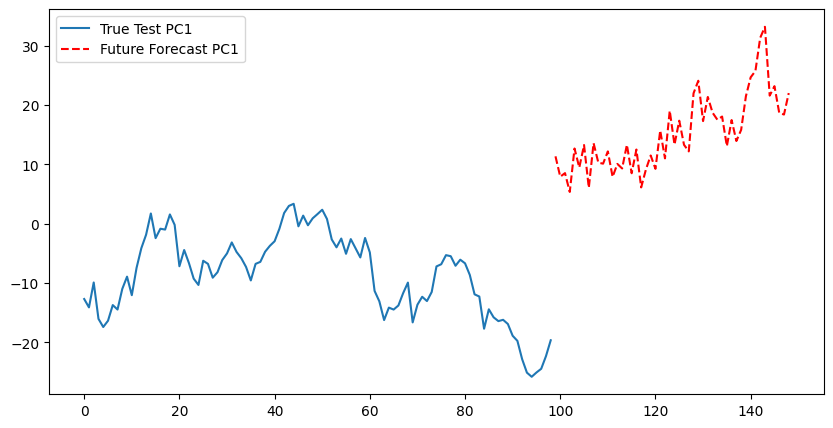

In [117]:
future_predictions = np.array(future_predictions)

plt.figure(figsize=(10,5))
plt.plot(Y_test[:,0], label="True Test PC1")
plt.plot(range(len(Y_test), len(Y_test)+H),
         future_predictions[:,0], 'r--', label="Future Forecast PC1")
plt.legend()
plt.show()

In [118]:
# Reconstruct from PCA
future_surface_scaled = pca.inverse_transform(future_predictions)

# Undo scaling
future_surface = scaler.inverse_transform(future_surface_scaled)

In [121]:
print(future_surface.shape)

(50, 224)


In [120]:
horizon = 10  # 10 days ahead

surface_h = future_surface[horizon]

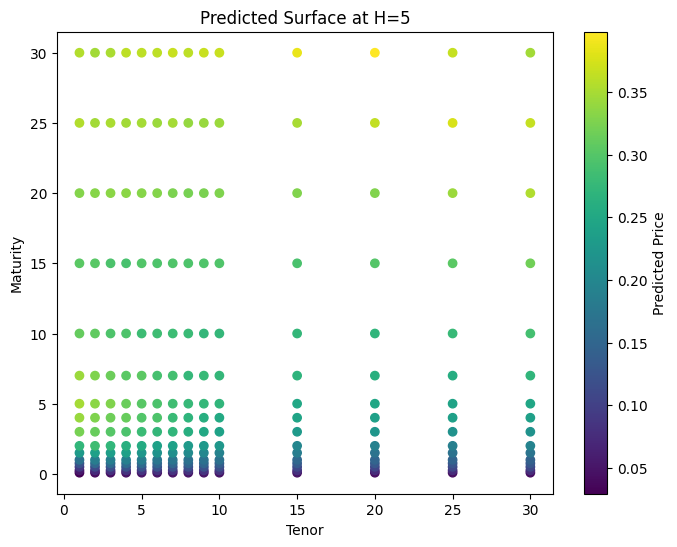

In [129]:
horizon = 5
surface_h = future_surface[horizon]

plt.figure(figsize=(8,6))
plt.scatter(tenors, maturities, c=surface_h, cmap="viridis")
plt.colorbar(label="Predicted Price")
plt.xlabel("Tenor")
plt.ylabel("Maturity")
plt.title(f"Predicted Surface at H={horizon}")
plt.show()

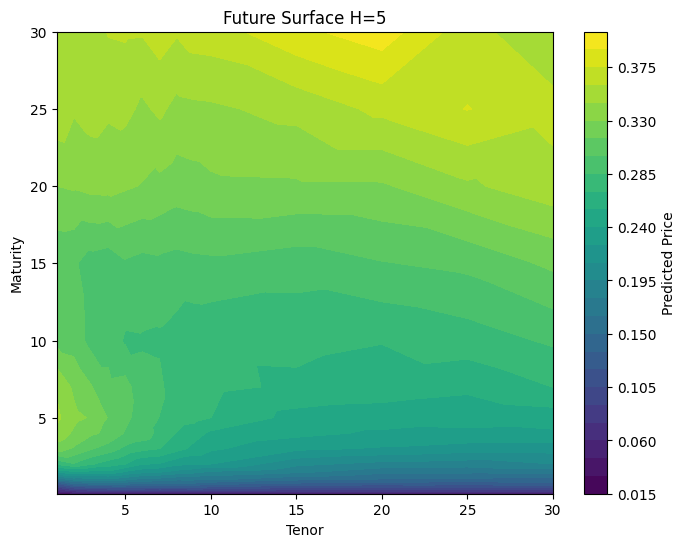

In [130]:
import matplotlib.tri as mtri

tri = mtri.Triangulation(tenors, maturities)

plt.figure(figsize=(8,6))
plt.tricontourf(tri, surface_h, levels=30, cmap="viridis")
plt.colorbar(label="Predicted Price")
plt.xlabel("Tenor")
plt.ylabel("Maturity")
plt.title(f"Future Surface H={horizon}")
plt.show()